## A Simple Circuit

Let's build a simple two qubit circuit, with a Hadamard and a CNOT Gate

![img](https://docs.quantinuum.com/guppy/_images/getting_started_circuit.png)

To make this cricuit, we would need a `@guppy` decorator. You can see there's also a mid circuit measurement

In [1]:
from guppylang import guppy
from guppylang.std.builtins import result
from guppylang.std.quantum import cx, h, measure, qubit, x # here lies all the gates!!

In [2]:
@guppy
def simple_circuit() -> qubit:
    q1, q2 = qubit(), qubit()
    h(q1)
    cx(q1,q2)

    outcome = measure(q1)
    result("q1", outcome)

    if outcome:
        x(q2)
    return q2
simple_circuit.check()

For execution, we can write a function that calls the circuit, and measures the qubit

In [3]:
@guppy
def evaluate() -> None:
    q = simple_circuit()
    result("q2", measure(q))

Now, we can emulate our circuit using the stabilizer simulation

In [4]:
emulator = evaluate.emulator(n_qubits=2).stabilizer_sim().with_seed(135)
sim_result = emulator.run()
list(sim_result.results)

[QsysShot(entries=[('q1', 1), ('q2', 0)])]

We can send in multiple shots

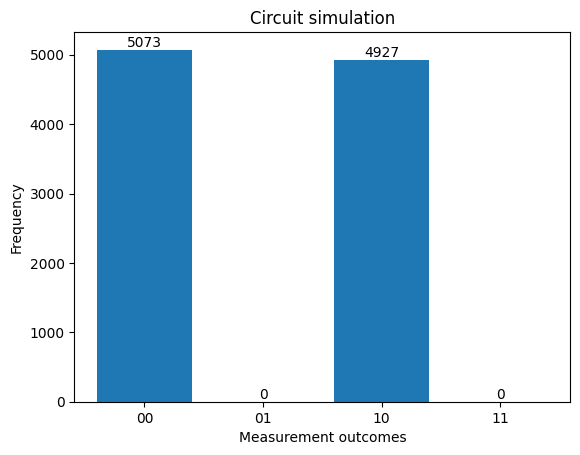

In [5]:
import matplotlib.pyplot as plt
import numpy as np 

shots = evaluate.emulator(n_qubits=2).with_seed(229).with_shots(10000).run()

fig,ax = plt.subplots(1,1)
possible_outcomes = ["00", "01", "10", "11"]
idx = np.asarray(list(range(len(possible_outcomes))))
counts = [len([1 for shot in shots if str(shot.as_dict()['q1']) + str(shot.as_dict()['q2']) == o]) for o in possible_outcomes]

bars = ax.bar(idx, counts)
ax.bar_label(bars, labels=counts)

ax.set_title("Circuit simulation")
ax.set_xlabel("Measurement outcomes")
ax.set_xticks(idx)
ax.set_xticklabels(possible_outcomes)
ax.set_ylabel("Frequency")
plt.show()

